In [33]:

from simbanator.analysis import HDF5BuildHistory
from simbanator.io.simba import Simulation

# Load your simulation (use the name you configured)
sim = Simulation("pc39")  # Replace XX with your snapshot number


hist = HDF5BuildHistory(sim)
hist.get_history_indx([0, 1], 45, 149)

z, props = hist.get_property_history({
    'galaxy_data': ['masses.stellar', 'sfr'],
    'halo_data':   ['masses.total'],
}, verbose=1)

# Interpolate stellar mass at z=0.5
hist.propr_from_z('masses.stellar', 0.2)



  snap 45: /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_045.hdf5
  snap 46: /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_046.hdf5
  snap 47: /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_047.hdf5
  snap 48: /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_048.hdf5
  snap 49: /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_049.hdf5
  snap 50: /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_050.hdf5
  snap 51: /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_051.hdf5
  snap 52: /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_052.hdf5
  snap 53: /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_053.hdf5
  snap 54: /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_054.hdf5
  snap 55: /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_055.hdf5
  snap 56: /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_056.hdf5
  snap 57: /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_057.hdf5
  snap 58: /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_058.hdf5
  snap 59: /media/lorenzong/Data1/SIMBA_catalogs

array([4.01738658e+12, 3.68700084e+12])

In [ ]:
print(props['sfr'][:,0])


[1.32962231e+03 1.18099072e+03 1.12454321e+03 5.52362610e+02
 8.87661987e+02 8.69400696e+02 1.16107202e+03 8.11109619e+02
 1.55681714e+03 1.54541724e+03 2.32888379e+03 1.78895276e+03
 2.07465845e+03 1.29372791e+03 1.66941272e+03 8.03570312e+02
 8.82249573e+02 2.90048462e+02 4.89139771e+02 3.94501007e+02
 2.67400818e+02 1.67409943e+02 1.45915833e+02 1.61160583e+02
 4.16742279e+02 3.87995728e+03 4.77482275e+03 2.76636426e+03
 1.74163611e+03 9.07125427e+02 5.23220703e+02 6.26533630e+02
 5.08435669e+02 3.89491577e+02 2.95833405e+02 2.33677185e+02
 1.17198448e+02 6.71295624e+01 8.57832260e+01 4.86426964e+01
 4.67196703e-01 3.46081674e-01 6.53137207e-01 3.84144709e-02
 3.55830155e-02 0.00000000e+00 0.00000000e+00 3.75106968e-02
 3.75201590e-02 0.00000000e+00 0.00000000e+00 9.58529663e+00
 1.31382093e-01 0.00000000e+00 0.00000000e+00 1.79726505e+01
 2.95107899e+01 0.00000000e+00 5.84746819e+01 1.17243011e+02
 2.11058960e+02 1.35592185e-02 1.58168003e-02 0.00000000e+00
 0.00000000e+00 0.000000

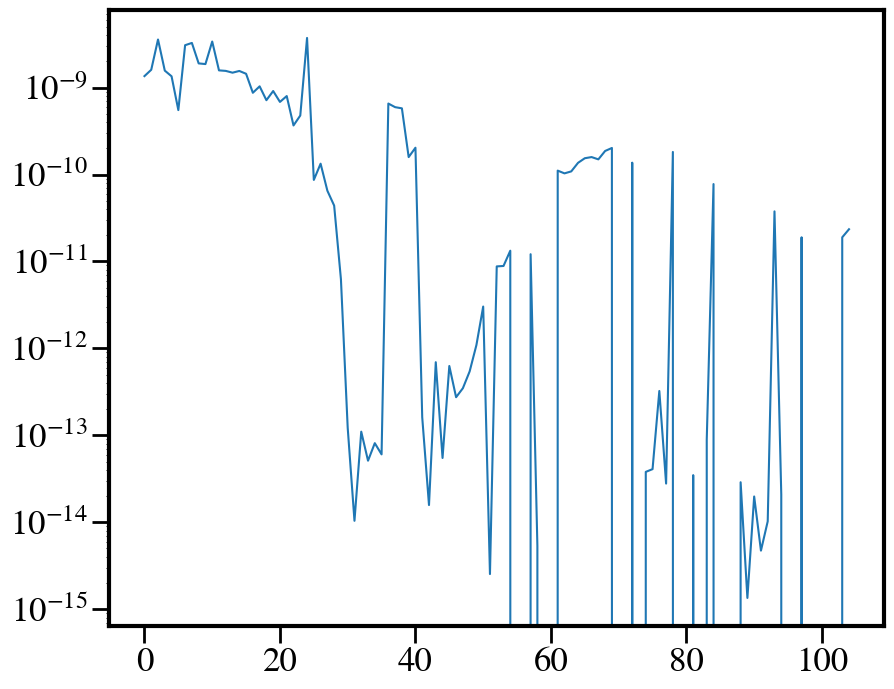

In [51]:
from matplotlib import pyplot as plt
plt.plot(props['sfr'][:,1]/props['masses.stellar'][:,1])
plt.yscale('log')

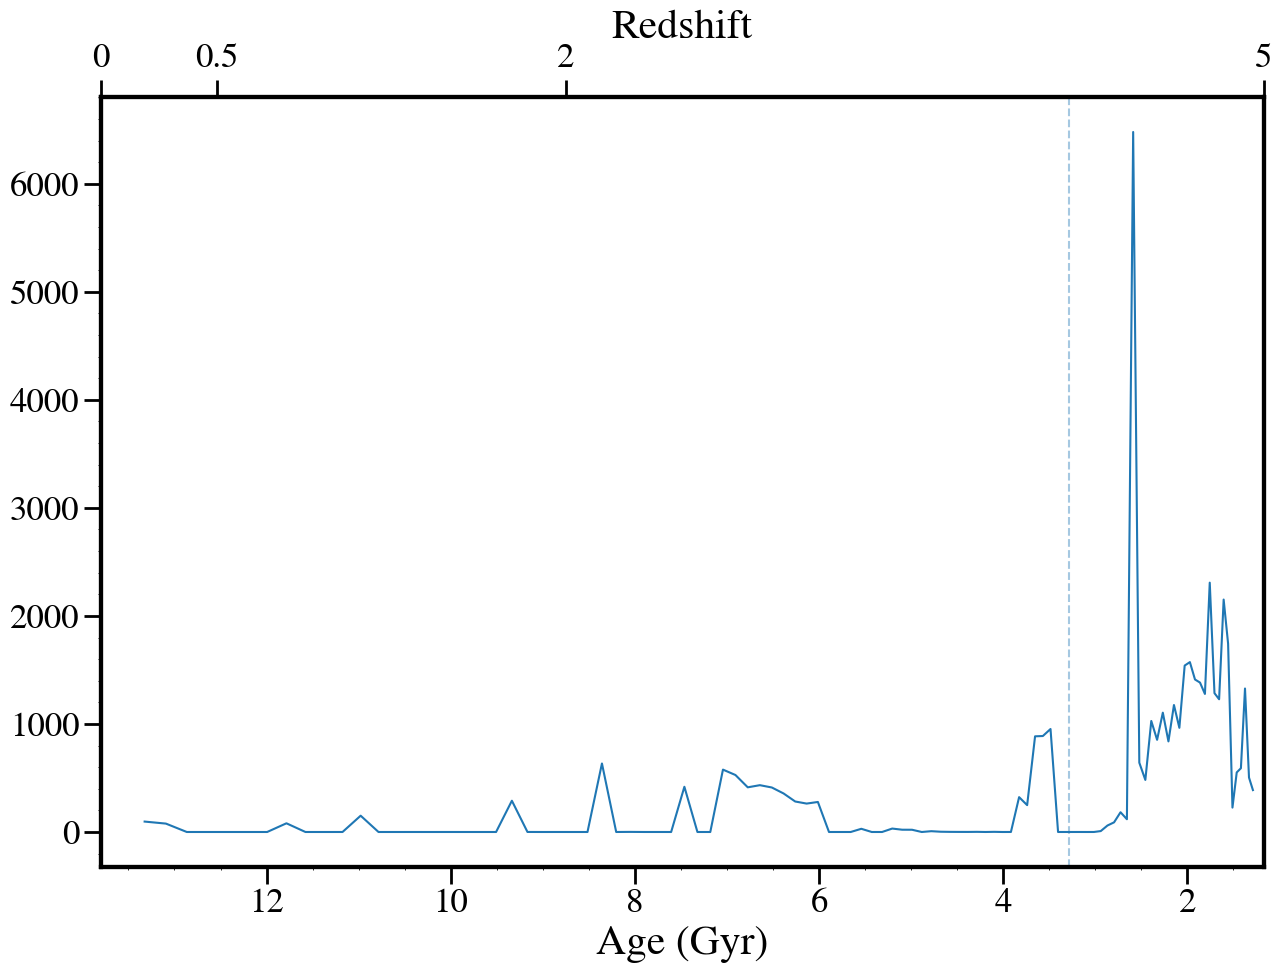

In [45]:


hist.plot_history(zlist=[0, 0.5, 2, 5], propr='sfr', outname='stellar_mass_history.png', indx=1)

In [29]:
from simbanator.analysis import caesar_read_progen

caesar_read_progen([0, 1], 'progenitors_most_mass', range(44, 150), sim, output_dir=None)

yt : [INFO     ] 2026-03-11 18:16:12,645 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_149.hdf5
yt : [INFO     ] 2026-03-11 18:16:12,661 Found 466460 halos
yt : [INFO     ] 2026-03-11 18:16:12,664 Found 55061 galaxies
yt : [INFO     ] 2026-03-11 18:16:13,013 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_148.hdf5
yt : [INFO     ] 2026-03-11 18:16:13,019 Found 467847 halos
yt : [INFO     ] 2026-03-11 18:16:13,022 Found 54406 galaxies
yt : [INFO     ] 2026-03-11 18:16:13,357 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_147.hdf5
yt : [INFO     ] 2026-03-11 18:16:13,363 Found 469318 halos
yt : [INFO     ] 2026-03-11 18:16:13,366 Found 54032 galaxies
yt : [INFO     ] 2026-03-11 18:16:13,759 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_146.hdf5
yt : [INFO     ] 2026-03-11 18:16:13,765 Found 470662 halos
yt : [INFO     ] 2026-03-11 18:16:13,768 Found 53653 galaxies
yt : [INFO     ] 2026-03-11 18:16:14,080 Opening /media/lorenzong/Data1/SIMBA_catalogs/m

In [44]:
import h5py
import numpy as np
snap = 45
s = []
for snap in range(45, 149):
    with h5py.File(f'/media/lorenzong/Data1/SIMBA_catalogs/m100n1024_{snap:03d}.hdf5', 'r') as f:
        tree = f['tree_data']['progen_galaxy_star']
        sfr = f['galaxy_data']['sfr']
        print(sfr[:3])
        s.append(sfr[0])
        #print(tree[:10])
print(np.max(s))

[1329.62231445  387.69168091 1556.02746582]
[1180.99072266  858.47509766  503.67419434]
[1124.54321289 1328.06286621  419.07910156]
[552.36260986 590.07104492 867.50494385]
[ 887.6619873   551.46484375 1146.63391113]
[ 869.4006958  3838.76806641  920.32122803]
[1161.07202148 1743.04663086 1218.58752441]
[2151.25732422  811.10961914 1174.43188477]
[1556.81713867 1228.50476074  980.84844971]
[1545.41723633 1866.15234375 1285.01513672]
[2328.88378906 1573.62353516 2307.78955078]
[1788.95275879 1896.06005859 1277.7244873 ]
[2074.65844727 1382.87487793 1300.5637207 ]
[1293.72790527 1411.38830566 1061.44641113]
[1669.41271973 1572.36254883  959.77270508]
[ 803.5703125  1540.37084961  887.00714111]
[ 882.24957275  964.26361084 1005.19055176]
[ 290.04846191 1175.35778809  655.51928711]
[489.13977051 838.31878662 527.52978516]
[ 394.50100708 1104.52880859  391.77957153]
[267.40081787 853.08581543 263.35299683]
[ 167.40994263 1027.69909668  351.29296875]
[145.91583252 481.83074951 374.17800903]
